[[0.043082142857142854, np.float64(53.43666163), np.float64(-2.22416998)], [0.0523875, np.float64(53.45156846), np.float64(-2.22233599)], [0.051239999999999994, np.float64(53.45335535), np.float64(-2.2233241)], [0.01, 53.45927628199057, -2.2276463370981574], [0.01, 53.4645870298434, -2.2320827813567172]]
[184, 21, 72, 65]
[0, 184, 205] [0.043082142857142854, 0.0523875, 0.051239999999999994]
[0.04308214 0.04322664 0.04337011 0.04351255 0.04365397 0.04379436
 0.04393373 0.04407206 0.04420937 0.04434566 0.04448092 0.04461515
 0.04474835 0.04488053 0.04501168 0.04514181 0.04527091 0.04539898
 0.04552603 0.04565205 0.04577704 0.04590101 0.04602395 0.04614586
 0.04626675 0.04638661 0.04650545 0.04662325 0.04674003 0.04685579
 0.04697052 0.04708422 0.04719689 0.04730854 0.04741917 0.04752876
 0.04763733 0.04774487 0.04785139 0.04795688 0.04806134 0.04816478
 0.04826719 0.04836858 0.04846893 0.04856826 0.04866657 0.04876385
 0.0488601  0.04895532 0.04904952 0.04914269 0.04923484 0.04932596
 0.

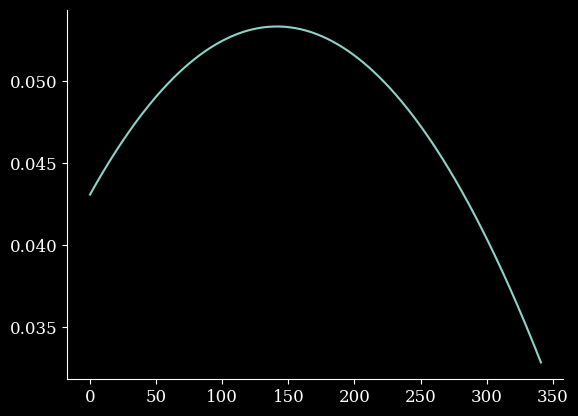

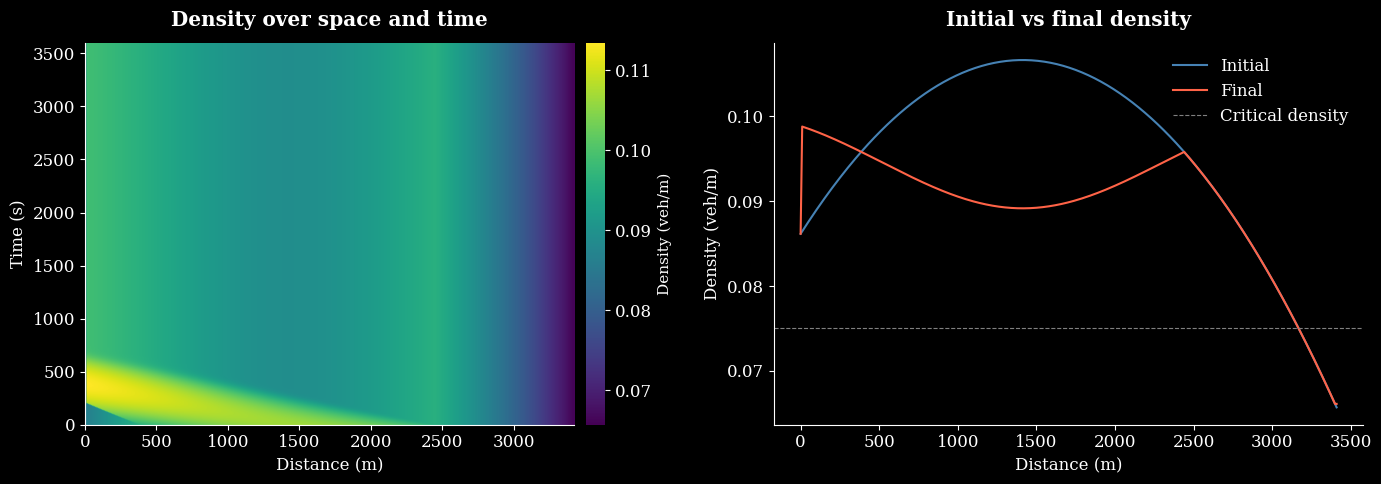

0 0
0 1
0 2
1 3
1 4
1 5
2 6
2 7
3 8
3 9
3 10
4 11
4 12
4 13
5 14
5 15
6 16
6 17
6 18
7 19
7 20
7 21
8 22
8 23
9 24
9 25
9 26
10 27
10 28
10 29
11 30
11 31
11 32
12 33
12 34
13 35
13 36
13 37
14 38
14 39
14 40
15 41
15 42
15 43
16 44
16 45
17 46
17 47
17 48
18 49
18 50
18 51
19 52
19 53
19 54
20 55
20 56
20 57
21 58
21 59
21 60
22 61
22 62
22 63
23 64
23 65
24 66
24 67
24 68
25 69
25 70
25 71
25 72
26 73
26 74
26 75
27 76
27 77
27 78
27 79
28 80
28 81
28 82
29 83
29 84
29 85
29 86
30 87
30 88
30 89
31 90
31 91
31 92
31 93
32 94
32 95
32 96
32 97
33 98
33 99
33 100
34 101
34 102
34 103
34 104
35 105
35 106
35 107
35 108
36 109
36 110
36 111
36 112
37 113
37 114
37 115
38 116
38 117
38 118
38 119
39 120
39 121
39 122
39 123
40 124
40 125
40 126
40 127
41 128
41 129
41 130
41 131
42 132
42 133
42 134
42 135
43 136
43 137
43 138
43 139
44 140
44 141
44 142
44 143
45 144
45 145
45 146
45 147
46 148
46 149
46 150
46 151
47 152
47 153
47 154
47 155
48 156
48 157
48 158
48 159
49 160
49 161
49 

In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# print("Python path:", sys.path)
# print("Parent folder contents:", os.listdir('..'))
# print("Current folder:", os.getcwd())

import inspect
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from src.lwr_model import density_array_polynomial, density_array_linear
from src.lwr_model import FREE_SPEEDS, CELL_SIZE
from src.lwr_model.CTM import CTM_model

# --- Real world density ---
whole_density_arr, _ = density_array_polynomial()
# --- Model setup ---
density_init = np.array(whole_density_arr) *2
N = len(density_init)
cell_widths = np.full(N, CELL_SIZE)

v_free = min(FREE_SPEEDS.values()) * (1000/3600)
jam_density = 0.15
max_flow = v_free * jam_density / 6
inlet_density = density_init[0]
simulation_time = 60*60

# --- Run ---
model = CTM_model(cell_widths, density_init, jam_density, max_flow, v_free)
model.run(inlet_density=inlet_density, total_time=simulation_time)
print(whole_density_arr)
# --- Plot ---

plt.plot(whole_density_arr)

history = np.array(model.history)
distance = np.arange(N) * CELL_SIZE

mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
im = axes[0].imshow(
    history,
    aspect='auto',
    origin='lower',
    extent=[0, N * CELL_SIZE, 0, len(history) * model.step_width],
    cmap='viridis'
)
cbar = fig.colorbar(im, ax=axes[0], pad=0.02)
cbar.set_label('Density (veh/m)', fontsize=11)
cbar.outline.set_visible(False)
axes[0].set_xlabel('Distance (m)')
axes[0].set_ylabel('Time (s)')
axes[0].set_title('Density over space and time', fontweight='bold', pad=12)

# Initial vs final
axes[1].plot(distance, history[0], label='Initial', color='steelblue', linewidth=1.5)
axes[1].plot(distance, history[-1], label='Final', color='tomato', linewidth=1.5)
axes[1].axhline(jam_density / 2, color='grey', linestyle='--', linewidth=0.8, label='Critical density')
axes[1].set_xlabel('Distance (m)')
axes[1].set_ylabel('Density (veh/m)')
axes[1].set_title('Initial vs final density', fontweight='bold', pad=12)
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

# --- Travel time ---
travel = model.travel_time(start_cell=0, end_cell=N-1, start_time=0)
print(N,CELL_SIZE)
print(f"Road length: {N * CELL_SIZE}m")
print(f"Travel time: {travel/60:.2f} min" if travel else "Vehicle did not reach end within simulation")